In [1]:
import pandas as pd

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
stressLvlDf = pd.read_csv("../data/raw/StressLevelDataset.csv")

In [4]:
train_df = pd.read_csv('../results/outputs/Stress_level_dataset_featured/stress_level_train_featured.csv')

In [5]:
test_df = pd.read_csv('../results/outputs/Stress_level_dataset_featured/stress_level_test_featured.csv')

In [6]:
scaledStressData = pd.read_csv("../results/outputs/stress_dataset_scaled_full_Stress_Level_dataset.csv")

In [7]:
train_df.head()

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,social_support,peer_pressure,extracurricular_activities,bullying,target,mental_health_score,physical_score,environment_score,academic_score,social_score
0,0.314428,0.795832,1,-0.333345,-0.349524,-1.430923,-0.426886,-0.521307,-0.489063,-0.462047,...,0.118375,0.187084,0.163779,-0.413484,1,0.444229,-0.682160,-0.330784,-0.119688,0.013938
1,1.282463,-0.771658,1,1.611905,1.081086,0.979053,-1.074576,1.625730,1.764213,-1.351767,...,-0.837312,1.594209,1.563055,1.549820,2,0.780678,0.652823,-0.339384,0.052696,0.967443
2,-1.621643,0.795832,0,-1.241128,-1.064830,-0.225935,1.516182,-1.236986,-1.240155,1.317391,...,1.074062,-1.220041,-0.535859,-1.067918,0,-0.516735,-0.252892,0.630892,-0.116037,-0.437439
3,0.637107,-0.883621,1,0.574438,1.081086,0.979053,-1.074576,1.625730,1.764213,-1.351767,...,-0.837312,1.594209,0.863417,1.549820,2,0.331981,0.652823,-0.339384,0.063244,0.792533
4,-0.653607,1.019759,0,-1.630178,-1.064830,-0.225935,0.868493,-0.521307,-0.489063,0.427672,...,1.074062,-0.516479,-1.235497,-1.067918,0,-0.316007,-0.235895,0.596235,-0.116037,-0.436458


In [8]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 880 entries, 0 to 879
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   anxiety_level                 880 non-null    float64
 1   self_esteem                   880 non-null    float64
 2   mental_health_history         880 non-null    int64  
 3   depression                    880 non-null    float64
 4   headache                      880 non-null    float64
 5   blood_pressure                880 non-null    float64
 6   sleep_quality                 880 non-null    float64
 7   breathing_problem             880 non-null    float64
 8   noise_level                   880 non-null    float64
 9   living_conditions             880 non-null    float64
 10  safety                        880 non-null    float64
 11  basic_needs                   880 non-null    float64
 12  academic_performance          880 non-null    float64
 13  study

In [9]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   anxiety_level                 220 non-null    float64
 1   self_esteem                   220 non-null    float64
 2   mental_health_history         220 non-null    int64  
 3   depression                    220 non-null    float64
 4   headache                      220 non-null    float64
 5   blood_pressure                220 non-null    float64
 6   sleep_quality                 220 non-null    float64
 7   breathing_problem             220 non-null    float64
 8   noise_level                   220 non-null    float64
 9   living_conditions             220 non-null    float64
 10  safety                        220 non-null    float64
 11  basic_needs                   220 non-null    float64
 12  academic_performance          220 non-null    float64
 13  study

In [10]:
#Relationship with target

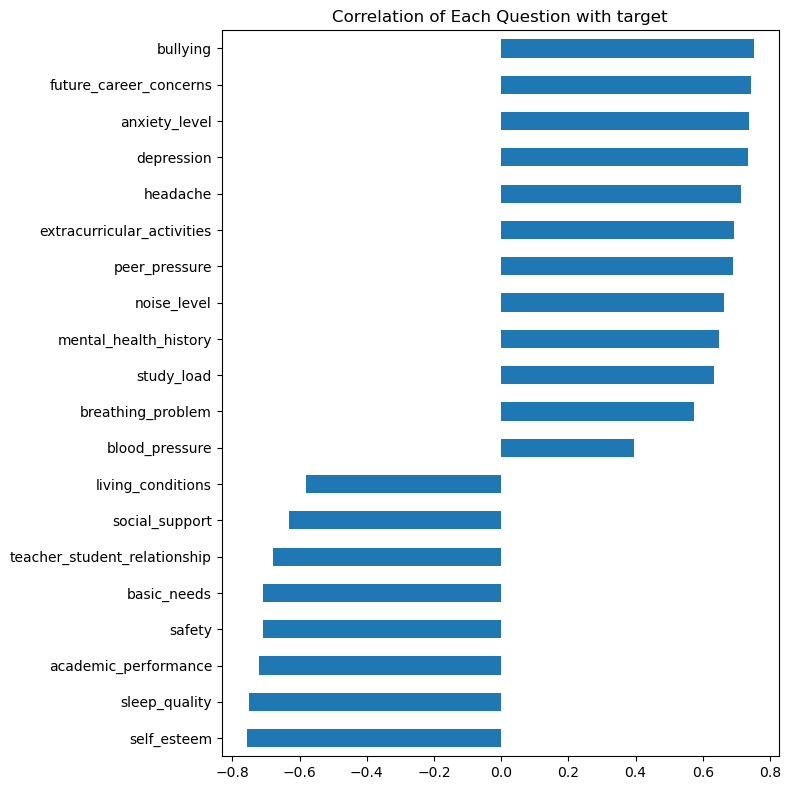

In [11]:
numeric_df = scaledStressData.drop(columns=["target"])
corrs = numeric_df.corrwith(scaledStressData["target"]).sort_values()

plt.figure(figsize=(8,8))
corrs.plot(kind='barh')
plt.title("Correlation of Each Question with target")
plt.tight_layout()
plt.show()

In [12]:
#Scatter plot

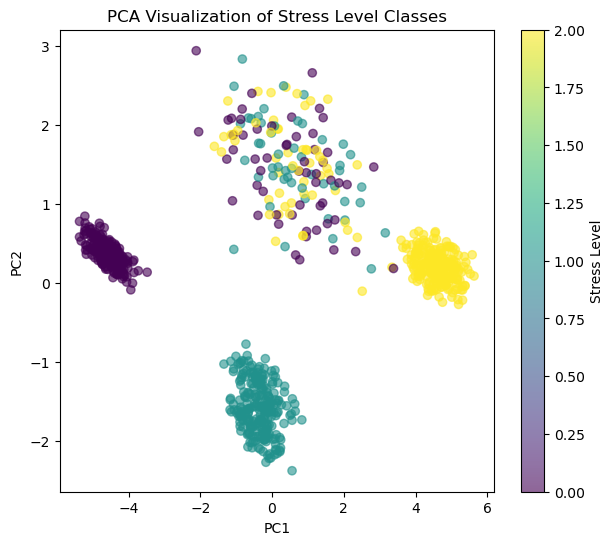

In [13]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

feature_cols = [c for c in train_df.columns if c != "target"]
pca = PCA(n_components=2)
components = pca.fit_transform(train_df[feature_cols])

plt.figure(figsize=(7,6))
plt.scatter(components[:,0], components[:,1], c=train_df["target"], cmap="viridis", alpha=0.6)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Visualization of Stress Level Classes")
plt.colorbar(label="Stress Level")
plt.show()

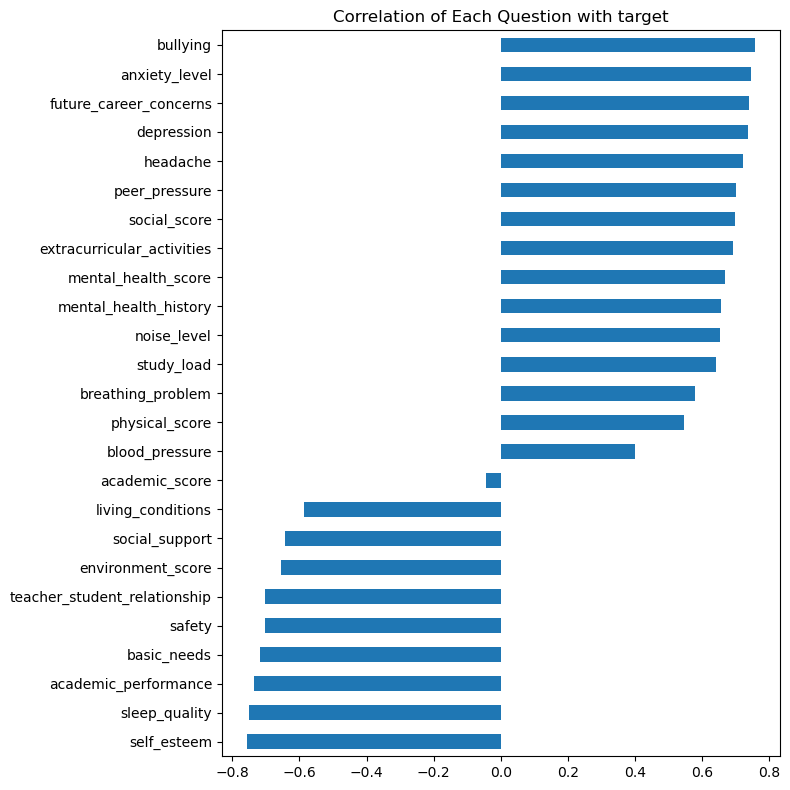

In [14]:
numeric_df = train_df.drop(columns=["target"])
corrs = numeric_df.corrwith(scaledStressData["target"]).sort_values()

plt.figure(figsize=(8,8))
corrs.plot(kind='barh')
plt.title("Correlation of Each Question with target")
plt.tight_layout()
plt.show()

In [15]:
#distrubution grid

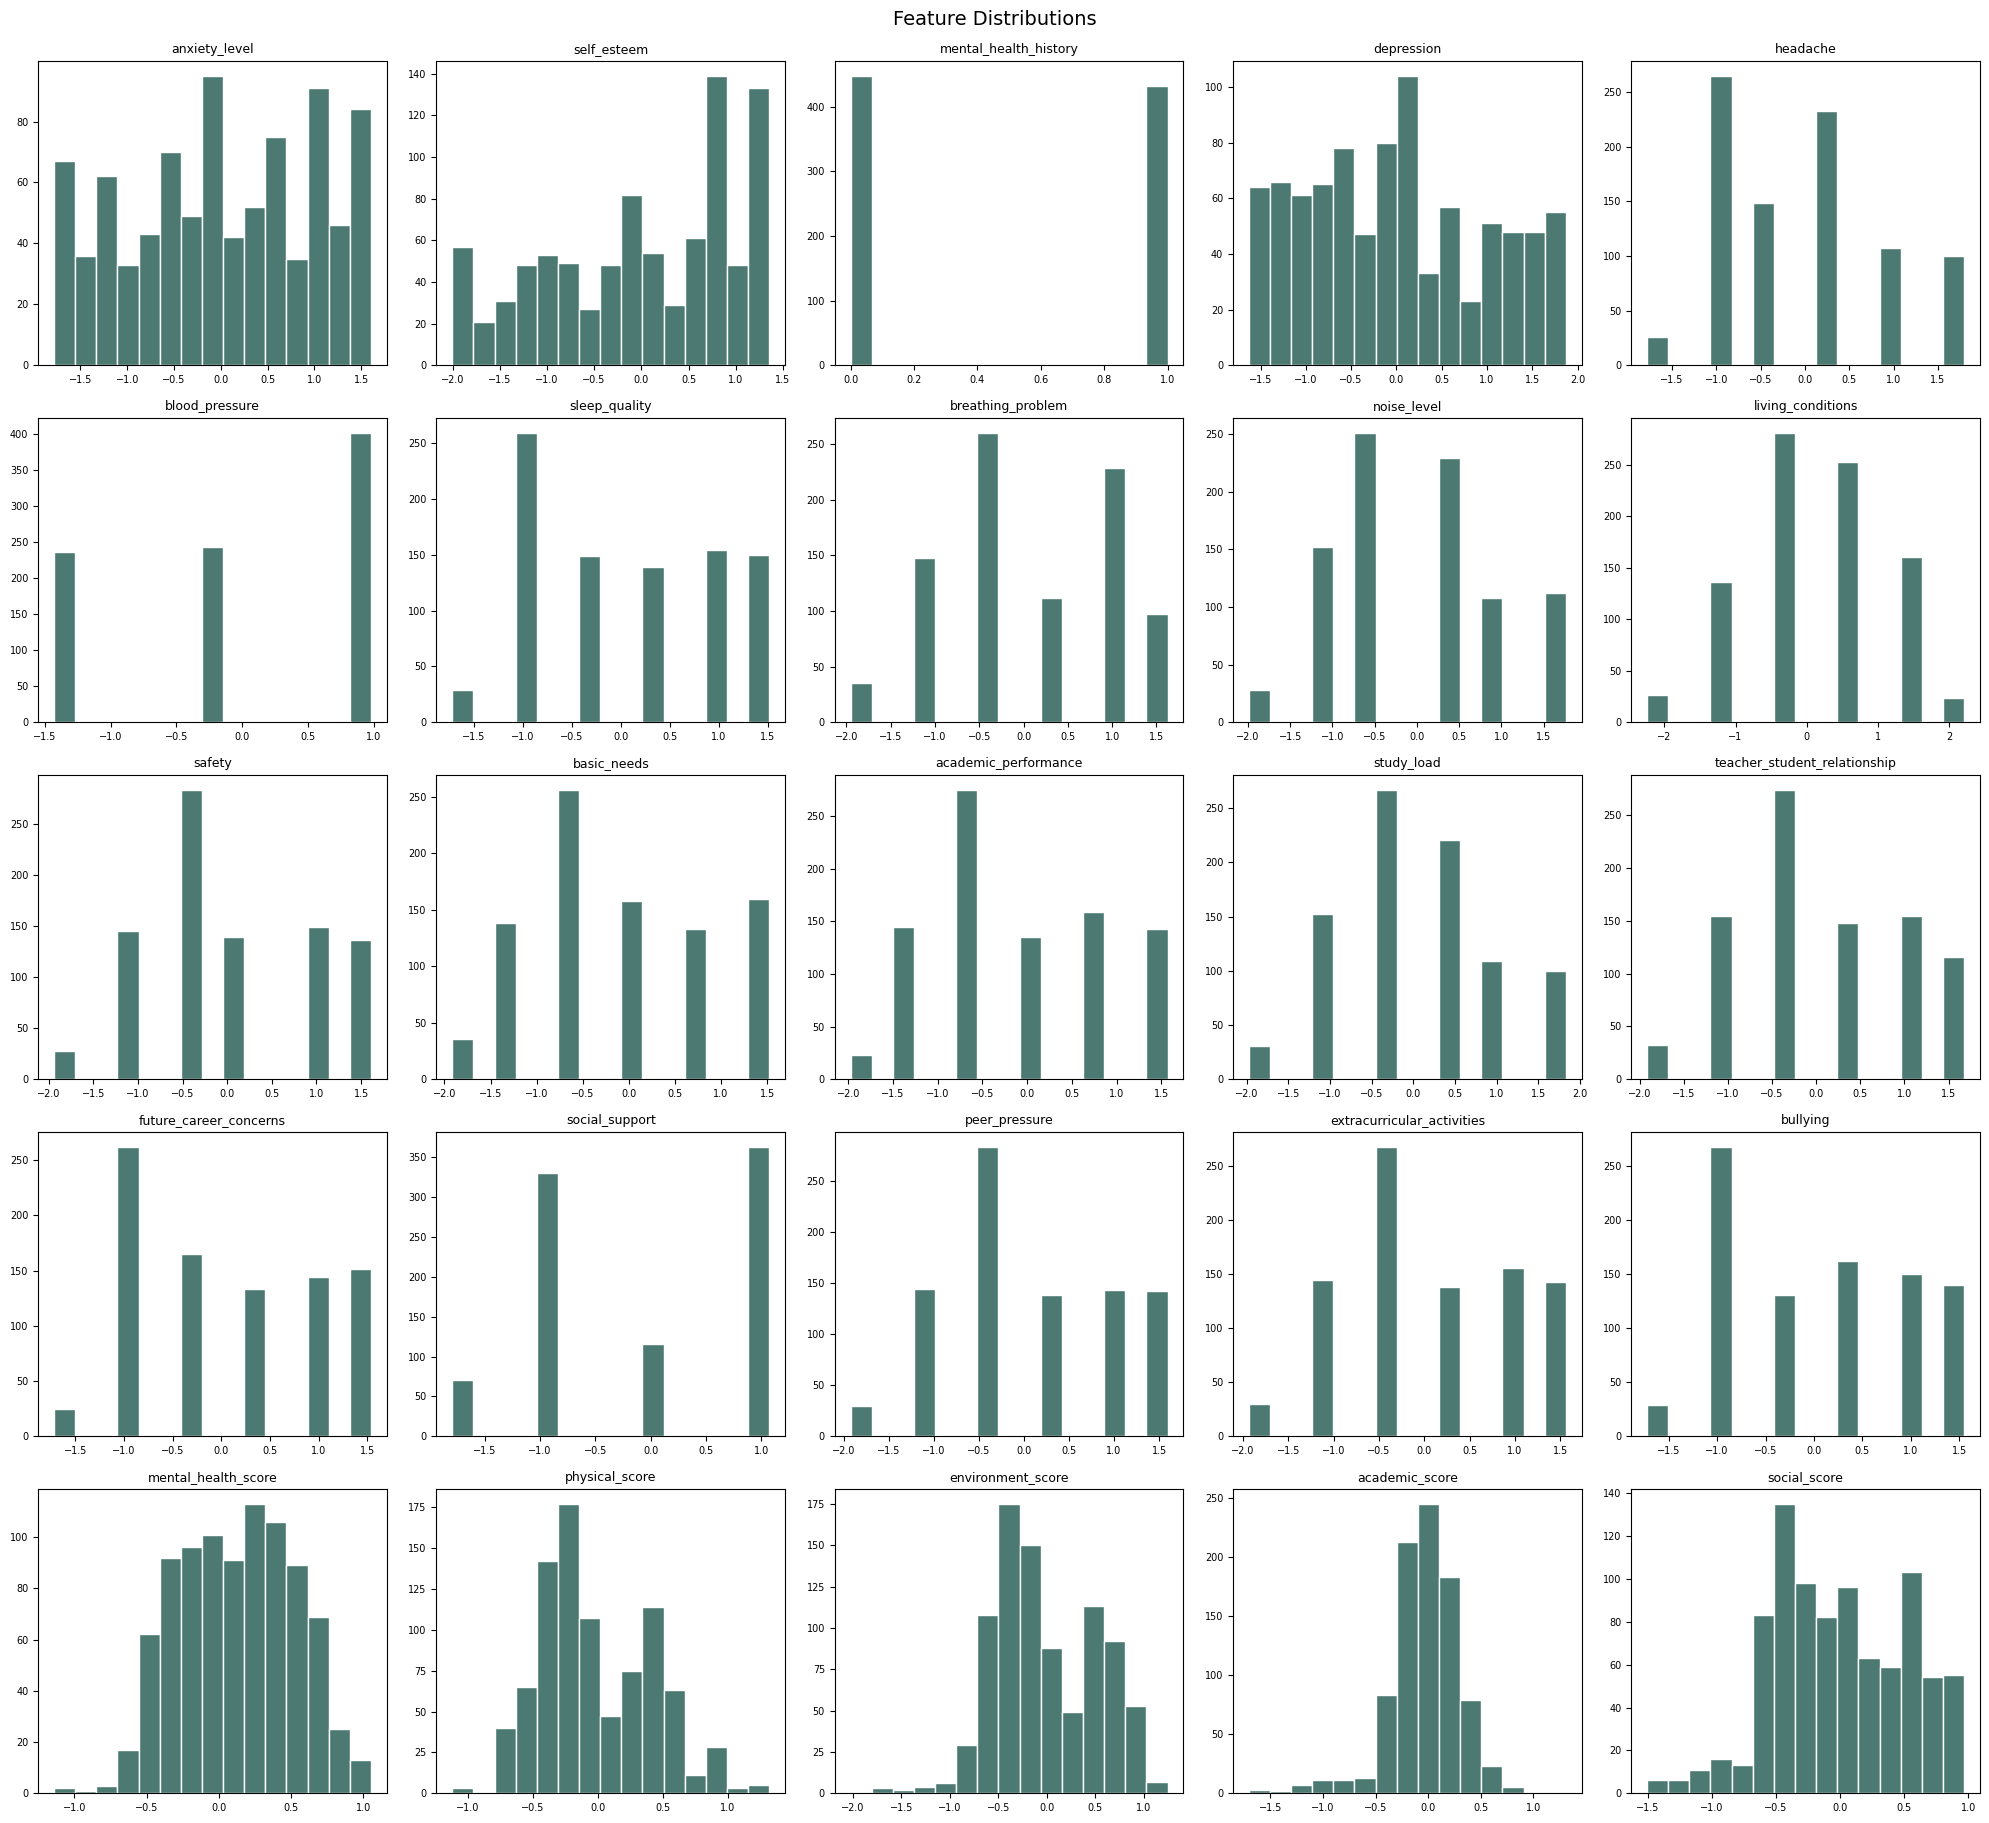

In [16]:
feature_cols = [c for c in train_df.columns if c != "target"] 

fig, axes = plt.subplots(5, 5, figsize=(20, 18))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].hist(train_df[col], bins=15, color='#4C7A73', edgecolor='white')
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(labelsize=7)

for j in range(len(feature_cols), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.suptitle("Feature Distributions", y=1.01, fontsize=14)
plt.show()

In [17]:
#Top features 

C:\Users\chand\AppData\Local\Temp\ipykernel_14724\1052896646.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="target", y=feat, data=train_df, ax=axes[i], palette="viridis")
C:\Users\chand\AppData\Local\Temp\ipykernel_14724\1052896646.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="target", y=feat, data=train_df, ax=axes[i], palette="viridis")
C:\Users\chand\AppData\Local\Temp\ipykernel_14724\1052896646.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="target", y=feat, data=train_df, ax=axes[i], palette="viridis")
C

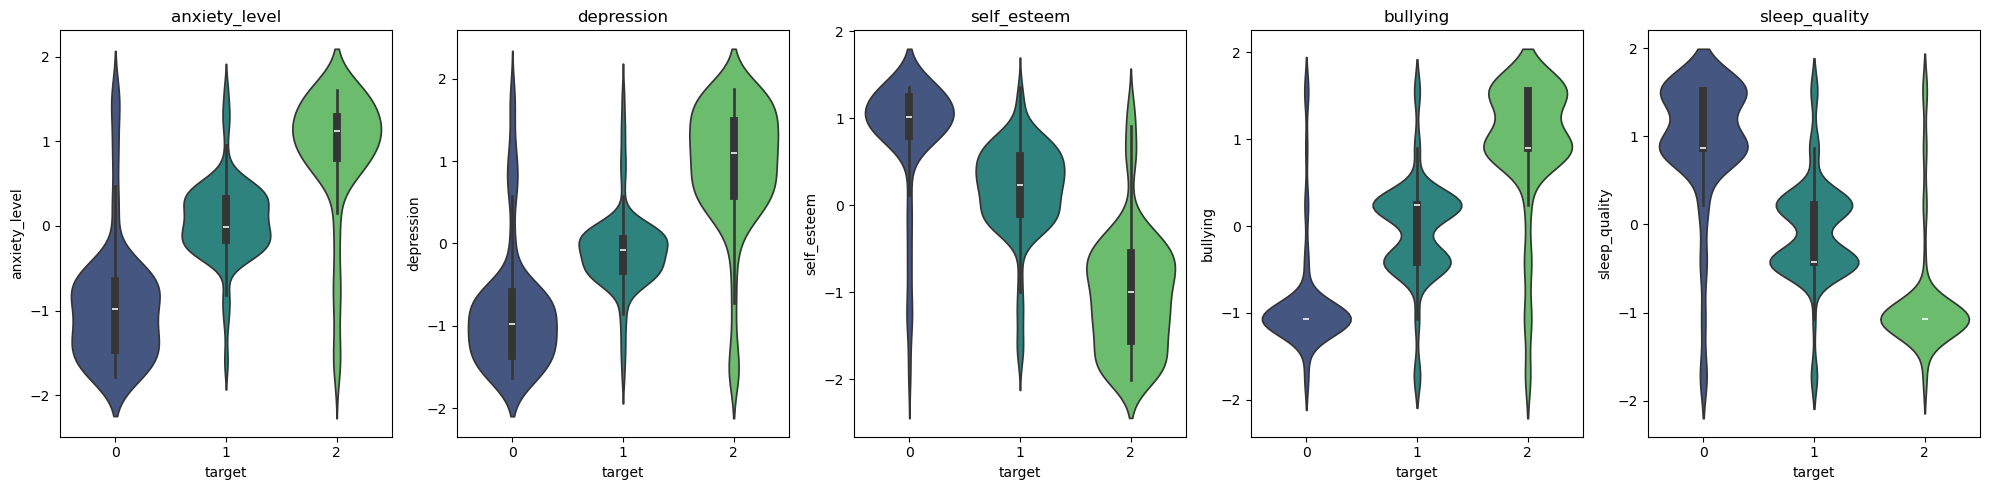

In [18]:
top_features = ["anxiety_level", "depression", "self_esteem", "bullying", "sleep_quality"]  # adjust to your top correlated features

fig, axes = plt.subplots(1, len(top_features), figsize=(20, 5))
for i, feat in enumerate(top_features):
    sns.violinplot(x="target", y=feat, data=train_df, ax=axes[i], palette="viridis")
    axes[i].set_title(feat)
plt.tight_layout()
plt.show()

In [19]:
#composite scores

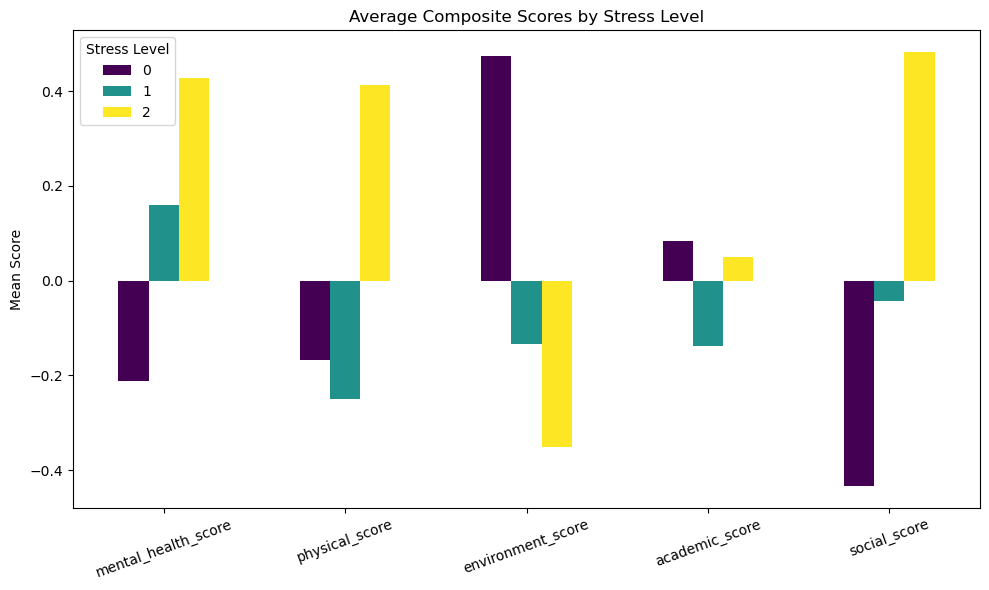

In [20]:
composite_cols = ["mental_health_score", "physical_score", "environment_score", "academic_score", "social_score"]

grouped = train_df.groupby("target")[composite_cols].mean()

grouped.T.plot(kind="bar", figsize=(10, 6), colormap="viridis")
plt.title("Average Composite Scores by Stress Level")
plt.ylabel("Mean Score")
plt.xticks(rotation=20)
plt.legend(title="Stress Level")
plt.tight_layout()
plt.show()

In [21]:
#getting top 5 features 

In [22]:
feature_cols = [c for c in train_df.columns if c != "target"] 

corrs = train_df[feature_cols].corrwith(train_df["target"])

top5 = corrs.abs().sort_values(ascending=False).head(5)
top5_signed = corrs[top5.index] 

print(top5_signed)

bullying                  0.756308
self_esteem              -0.755800
sleep_quality            -0.749263
anxiety_level             0.745616
future_career_concerns    0.738911
dtype: float64


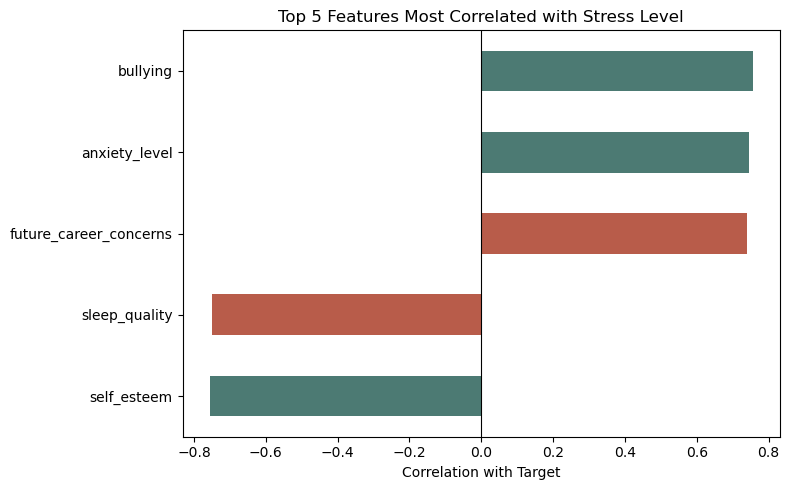

In [23]:
plt.figure(figsize=(8, 5))
colors = ['#B85C4A' if v < 0 else '#4C7A73' for v in top5_signed.values]
top5_signed.sort_values().plot(kind='barh', color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title("Top 5 Features Most Correlated with Stress Level")
plt.xlabel("Correlation with Target")
plt.tight_layout()
plt.show()

In [ ]:
#checing if feature selection needed 

social_score                    0.148798
blood_pressure                  0.101762
basic_needs                     0.070011
academic_performance            0.065106
depression                      0.059416
anxiety_level                   0.058256
teacher_student_relationship    0.054912
sleep_quality                   0.045777
self_esteem                     0.042834
headache                        0.042633
social_support                  0.040234
future_career_concerns          0.037683
physical_score                  0.036922
safety                          0.032877
extracurricular_activities      0.031092
bullying                        0.029331
peer_pressure                   0.025985
environment_score               0.015545
academic_score                  0.013060
mental_health_score             0.011627
study_load                      0.010032
breathing_problem               0.008240
noise_level                     0.008123
living_conditions               0.007542
mental_health_hi

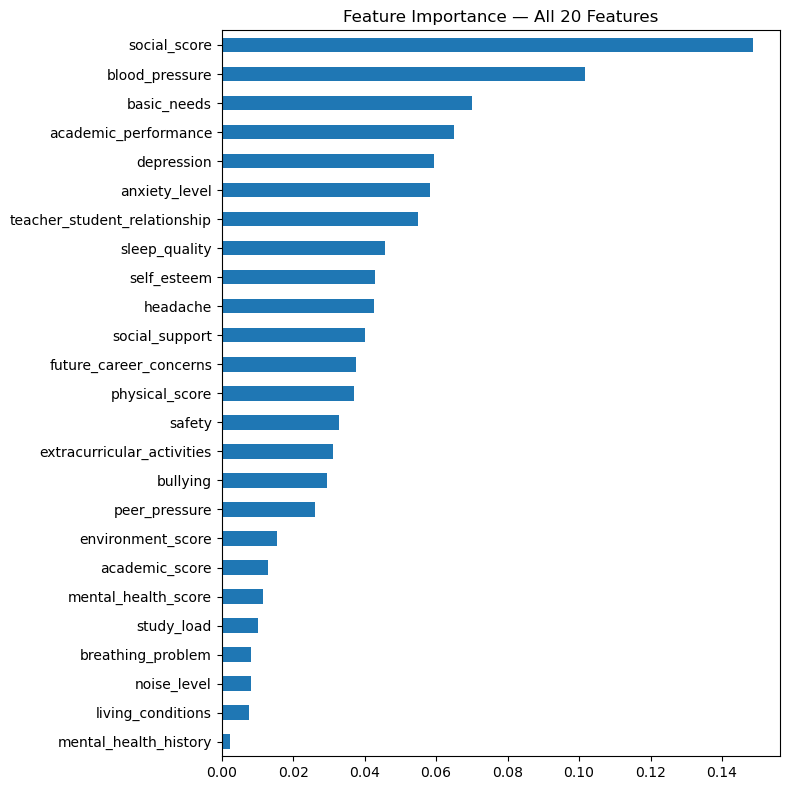

In [24]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt

feature_cols = [c for c in train_df.columns if c != "target"]
X = train_df[feature_cols]
y = train_df["target"]

rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(importances)

plt.figure(figsize=(8, 8))
importances.plot(kind='barh')
plt.title("Feature Importance — All 20 Features")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [25]:
from sklearn.model_selection import cross_val_score

top10 = importances.head(10).index.tolist()

full_score = cross_val_score(RandomForestClassifier(random_state=42), X, y, cv=5, scoring='accuracy').mean()
top10_score = cross_val_score(RandomForestClassifier(random_state=42), X[top10], y, cv=5, scoring='accuracy').mean()

print(f"Full feature set (20 features): {full_score:.4f}")
print(f"Top 10 features only:           {top10_score:.4f}")

Full feature set (20 features): 0.8795
Top 10 features only:           0.8739


In [ ]:
#this make surte that removing less helpfull features dosent change the training accuracy at all 

In [26]:
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

top10 = importances.head(10).index.tolist()

models = {
    "SVM": SVC(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Naive Bayes": GaussianNB()
}

results = []

for name, model in models.items():
    full_score = cross_val_score(model, X, y, cv=5, scoring='accuracy').mean()
    top10_score = cross_val_score(model, X[top10], y, cv=5, scoring='accuracy').mean()
    
    results.append({
        "Model": name,
        "Full (20 features)": full_score,
        "Top 10 features": top10_score,
        "Difference": top10_score - full_score
    })
    
    print(f"{name}")
    print(f"  Full feature set (20 features): {full_score:.4f}")
    print(f"  Top 10 features only:           {top10_score:.4f}")
    print(f"  Difference:                     {top10_score - full_score:+.4f}\n")

SVM
  Full feature set (20 features): 0.8727
  Top 10 features only:           0.8830
  Difference:                     +0.0102

KNN
  Full feature set (20 features): 0.8670
  Top 10 features only:           0.8784
  Difference:                     +0.0114

Logistic Regression
  Full feature set (20 features): 0.8761
  Top 10 features only:           0.8773
  Difference:                     +0.0011

Naive Bayes
  Full feature set (20 features): 0.8807
  Top 10 features only:           0.8830
  Difference:                     +0.0023



In [ ]:
#these are only miner improvements rather than changing keep these and improve the accuracy using hyper parameter tuning